# Notebook 7 — Topic Modeling with BERTopic

This notebook discovers thematic topics in our lyrics corpus **without supervision**. Unlike the emotion classifiers in notebook 6, which imposed external categories trained on tweets, here we let the data tell us what topics exist.

**Pipeline:**
1. Embed each song using a sentence-transformer (`all-MiniLM-L6-v2`)
2. Reduce dimensions with UMAP
3. Cluster with HDBSCAN
4. Label each cluster using class-TF-IDF (which words distinguish this cluster?)
5. Track each topic's prevalence over time

**Why this method:** unsupervised clustering doesn't suffer from the "trained on the wrong domain" problem we saw with VADER and emotion classifiers. The model has no preconceptions about what lyrics should mean.

**Output:** topic assignments per song, topic labels, and time-series of topic prevalence.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIGURES_DIR = Path.cwd().parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_parquet(PROCESSED_DIR / "songs_with_emotions.parquet")
df_en = df[df["language"] == "en"].copy().reset_index(drop=True)
print(f"English songs: {len(df_en):,}")

English songs: 6,538


## Generate embeddings

We use `all-MiniLM-L6-v2` — a small, fast, good-quality sentence transformer. Each lyric (truncated to ~256 tokens for speed) becomes a 384-dimensional vector.

This is the slowest step. Expect 3-5 minutes on CPU for 6500 songs.

Embeddings are cached to disk so re-runs are instant.

In [2]:
from sentence_transformers import SentenceTransformer

EMBEDDINGS_PATH = PROCESSED_DIR / "song_embeddings.npy"

if EMBEDDINGS_PATH.exists():
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f"Loaded cached embeddings: shape {embeddings.shape}")
    assert len(embeddings) == len(df_en), \
        f"Mismatch: {len(embeddings)} embeddings vs {len(df_en)} songs. Delete cache."
else:
    # The transformer truncates to 256 tokens automatically (its max)
    model = SentenceTransformer("all-MiniLM-L6-v2")
    
    # Use first ~1000 chars as the lyric "representative" 
    # (≈256 tokens for English text)
    texts = df_en["lyrics_text"].str[:1000].tolist()
    
    embeddings = model.encode(
        texts, 
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f"Saved embeddings: shape {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Saved embeddings: shape (6538, 384)


## Fit BERTopic

We configure a few key parameters:

- **`min_topic_size=30`**: a cluster needs at least 30 songs to be a "topic". Smaller clusters get merged into the outlier bin (-1). With ~6500 songs, this gives us maybe 30-60 topics.
- **`nr_topics="auto"`**: BERTopic will merge similar topics automatically.
- **Custom stopwords**: we want topics defined by *content* words, not "I", "you", "the". We extend the standard English stopword list.

This step is fast (a minute or two) since we already have embeddings.

In [10]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from sklearn.cluster import KMeans

# Custom stopwords: standard English + pop-music filler words
EXTRA_STOPWORDS = {
    "oh", "ooh", "yeah", "ah", "hey", "la", "na", "da", "ba", "do", "ra",
    "uh", "huh", "mm", "hmm", "ow", "wow", "whoa", "woah", "ay", "ayy",
    "doo", "boom", "bam", "ding", "dong", "bop",
    "im", "youre", "dont", "cant", "wont", "ill", "thats", "id", "youve",
    "got", "get", "gonna", "wanna", "gotta",
    "like", "just", "really", "even", "still", "way", "back", "right",
    "know", "say", "tell", "see", "feel", "go", "come", "make", "take",
    "give", "let", "put", "want", "need", "would", "could", "should", "one",
}

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
STOPWORDS = list(ENGLISH_STOP_WORDS) + list(EXTRA_STOPWORDS)

# Use PROPORTIONS not absolute counts — works whether vectorizer is fit on
# 6500 songs or on 12 grouped topic-documents.
vectorizer = CountVectorizer(
    stop_words=STOPWORDS,
    ngram_range=(1, 2),
    min_df=2,           # absolute count: word must appear in ≥2 documents
    max_df=0.95,        # proportion: word in <95% of documents
)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

# k-means forces every song into a cluster. We pick k=25 — more than the
# 11 topics HDBSCAN found, fewer than 50 (which would over-fragment).
# Some clusters will be loose, but every song gets a label.
hdbscan_model = KMeans(
    n_clusters=25,
    random_state=42,
    n_init=10,
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    nr_topics="auto",
    calculate_probabilities=False,
    verbose=True,
)

docs = df_en["lyrics_text"].str[:1000].tolist()
topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
df_en["topic"] = topics

print(f"\nDiscovered {len(set(topics)) - 1} topics (-1 = outlier)")
print(f"Outliers: {(np.array(topics) == -1).sum():,} of {len(topics)} songs "
      f"({(np.array(topics) == -1).mean()*100:.1f}%)")

2026-05-15 11:09:00,494 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-15 11:09:06,643 - BERTopic - Dimensionality - Completed ✓
2026-05-15 11:09:06,644 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-15 11:09:07,102 - BERTopic - Cluster - Completed ✓
2026-05-15 11:09:07,102 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-15 11:09:07,692 - BERTopic - Representation - Completed ✓
2026-05-15 11:09:07,693 - BERTopic - Topic reduction - Reducing number of topics
2026-05-15 11:09:07,699 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-15 11:09:08,228 - BERTopic - Representation - Completed ✓
2026-05-15 11:09:08,230 - BERTopic - Topic reduction - Reduced number of topics from 25 to 15



Discovered 14 topics (-1 = outlier)
Outliers: 0 of 6538 songs (0.0%)


## Inspect the topics

Print the top topics with their characteristic words and a few example songs each.

In [11]:
topic_info = topic_model.get_topic_info()
print(f"Number of topics (incl. outlier): {len(topic_info)}")
print(topic_info.head(30))

Number of topics (incl. outlier): 15
    Topic  Count                            Name  \
0       0   2841          0_love_baby_cause_girl   
1       1    540            1_girl_aint_ya_girls   
2       2    463       2_nigga_shit_bitch_niggas   
3       3    302     3_love_heart_fall_love love   
4       4    293          4_ive_think_cause_life   
5       5    293             5_said_man_town_old   
6       6    273      6_love_day_heart_love love   
7       7    266       7_dance_rock_boogie_shake   
8       8    249          8_love_shes_woman_baby   
9       9    240          9_aint_home_little_man   
10     10    231      10_world_live_life_believe   
11     11    230        11_love_cause_said_sorry   
12     12    207       12_shes_said_girl_low low   
13     13    100            13_wish_god_rock_day   
14     14     10  14_jingle_bell_christmas_holly   

                                       Representation  \
0   [love, baby, cause, girl, heart, ive, hold, lo...   
1   [girl, aint,

In [12]:
def show_topic(topic_id, n_examples=8):
    """Print topic words + example songs."""
    if topic_id == -1:
        print(f"\n--- Topic -1 (outliers) ---")
        sample = df_en[df_en["topic"] == -1].sample(n_examples, random_state=42)
        for _, r in sample.iterrows():
            print(f"  {r['year']}: '{r['title']}' by {r['artist']}")
        return
    
    words = topic_model.get_topic(topic_id)
    word_str = ", ".join([w for w, _ in words[:10]])
    songs_in_topic = df_en[df_en["topic"] == topic_id]
    
    print(f"\n--- Topic {topic_id} ({len(songs_in_topic)} songs) ---")
    print(f"Top words: {word_str}")
    print(f"Year range: {songs_in_topic['year'].min()}-{songs_in_topic['year'].max()}, "
          f"median {songs_in_topic['year'].median():.0f}")
    print(f"Examples:")
    for _, r in songs_in_topic.sample(min(n_examples, len(songs_in_topic)), 
                                       random_state=42).iterrows():
        print(f"  {r['year']}: '{r['title']}' by {r['artist']}")

# Show the top 15 largest topics
for topic_id in topic_info["Topic"].head(15):
    show_topic(topic_id)


--- Topic 0 (2841 songs) ---
Top words: love, baby, cause, girl, heart, ive, hold, love love, good, little
Year range: 1946-2024, median 1986
Examples:
  2009: 'Womanizer' by Britney Spears
  1954: 'Hernando's Hideaway' by Archie Bleyer
  1987: 'Meet Me Half Way' by Kenny Loggins
  1987: '(I Just) Died In Your Arms' by Cutting Crew
  1989: 'Don't Wanna Lose You' by Gloria Estefan
  2007: 'Thnks fr th Mmrs' by Fall Out Boy
  2003: 'Your Body Is a Wonderland' by John Mayer
  1978: 'Jack And Jill' by Raydio

--- Topic 1 (540 songs) ---
Top words: girl, aint, ya, girls, baby, man, cause, um, good, little
Year range: 1946-2024, median 2003
Examples:
  2012: 'Work Out' by J. Cole
  2022: 'Big Energy' by Latto
  1965: 'The Jolly Green Giant' by The Kingsmen
  2023: 'Players' by Coi Leray
  1954: 'The Little Shoemaker' by The Gaylords
  2022: 'In a Minute' by Lil Baby
  2001: 'Get Ur Freak On' by Missy Elliott
  1973: 'The Cisco Kid' by War

--- Topic 2 (463 songs) ---
Top words: nigga, shit,

## Manually annotate topics

After inspecting Cell 9's output, we give each topic a human-readable name based on its words + example songs. This isn't automated — *you fill in this dict based on what you see*.

The first time you run this notebook, leave the names as placeholder "Topic N" — then update after reviewing Cell 9.

In [13]:
# Fill these in after inspecting Cell 9's output.
# Examples of plausible names based on what BERTopic typically finds in pop:
TOPIC_NAMES = {
    0:  "Pop love (generic)",
    1:  "R&B / rap-pop crossover",
    2:  "Hip-hop / rap",
    3:  "Heartbreak ballads",
    4:  "Introspection / dark emotional",
    5:  "Storytelling / narrative",
    6:  "Devotional love (classic)",
    7:  "Dance / party",
    8:  "Third-person love",
    9:  "Country / Americana",
    10: "Existential / world-themed",
    11: "Apology / regret / kiss-off",
    12: "Mixed (low signal)",
    13: "Dark / cinematic",
    14: "Christmas classics",
}

# Apply names where defined; fall back to "Topic N"
def label_topic(t):
    if t == -1: return "Outlier"
    return TOPIC_NAMES.get(t, f"Topic {t}")

df_en["topic_label"] = df_en["topic"].apply(label_topic)
print("Topic distribution:")
print(df_en["topic_label"].value_counts().head(20))

Topic distribution:
topic_label
Pop love (generic)                2841
R&B / rap-pop crossover            540
Hip-hop / rap                      463
Heartbreak ballads                 302
Introspection / dark emotional     293
Storytelling / narrative           293
Devotional love (classic)          273
Dance / party                      266
Third-person love                  249
Country / Americana                240
Existential / world-themed         231
Apology / regret / kiss-off        230
Mixed (low signal)                 207
Dark / cinematic                   100
Christmas classics                  10
Name: count, dtype: int64


## How does each topic's prevalence change over time?

For each topic, plot the share of charting songs it represents per year.

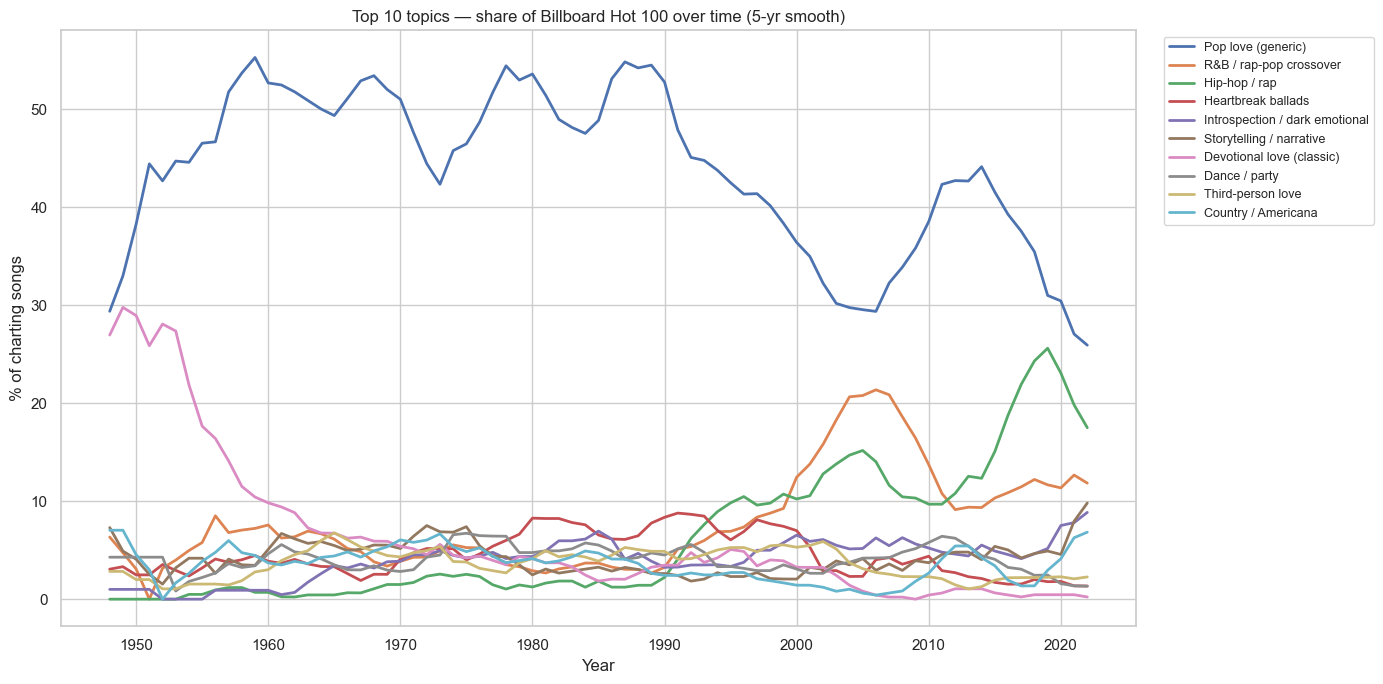

In [14]:
# Topic share per year (decimal)
topic_year = (df_en.groupby(["year", "topic"]).size()
                   .unstack(fill_value=0))
topic_year_pct = topic_year.div(topic_year.sum(axis=1), axis=0) * 100

# Show the biggest topics (excluding outliers)
top_topics = (df_en[df_en["topic"] != -1]
              .groupby("topic").size().nlargest(10).index.tolist())

fig, ax = plt.subplots(figsize=(14, 7))
for t in top_topics:
    label = TOPIC_NAMES.get(t, f"Topic {t}")
    smoothed = topic_year_pct[t].rolling(5, center=True).mean()
    ax.plot(smoothed.index, smoothed.values, linewidth=2, label=label)
ax.set_title("Top 10 topics — share of Billboard Hot 100 over time (5-yr smooth)")
ax.set_xlabel("Year"); ax.set_ylabel("% of charting songs")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
plt.tight_layout(); plt.show()

## Topic × decade heatmap

A more compact view: heatmap of topic share by decade.

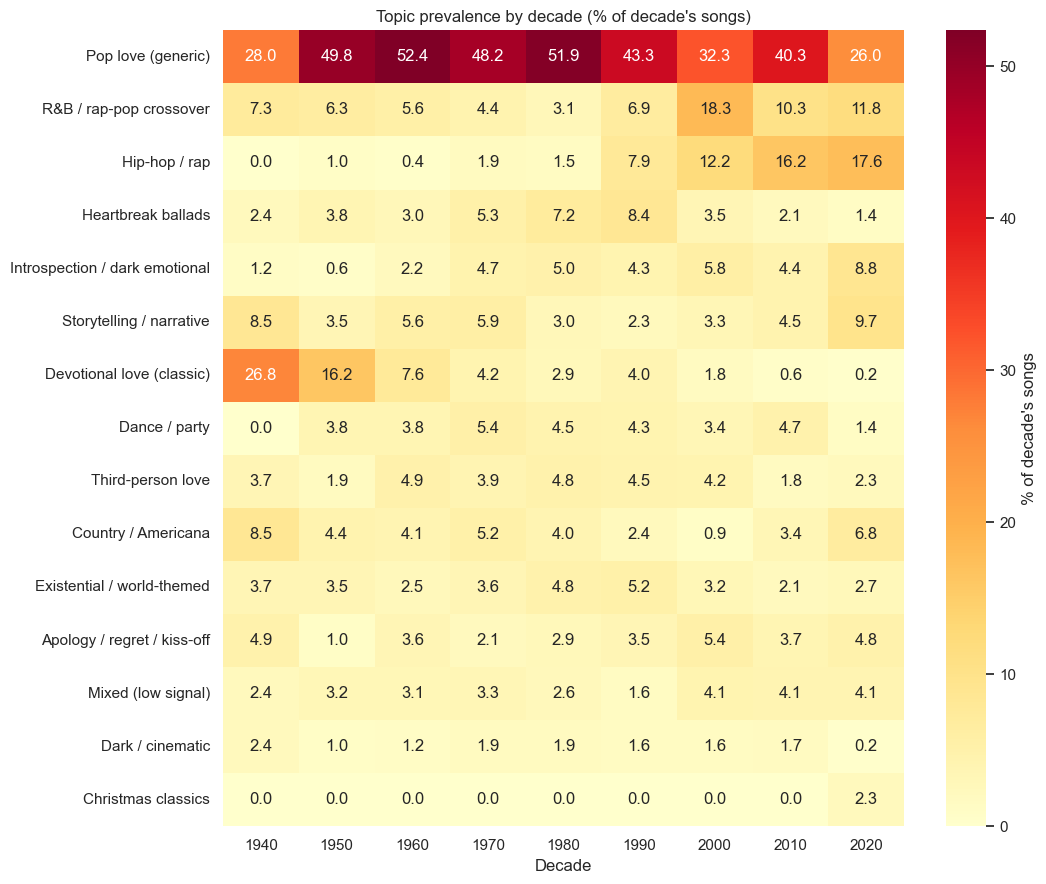

In [15]:
# Topic share per decade
topic_decade = (df_en[df_en["topic"] != -1]
                .groupby(["decade", "topic"]).size().unstack(fill_value=0))
topic_decade_pct = topic_decade.div(topic_decade.sum(axis=1), axis=0) * 100

# Restrict to the 20 largest topics
biggest = df_en[df_en["topic"] != -1]["topic"].value_counts().head(20).index
heatmap_data = topic_decade_pct[biggest].T

# Use topic labels
heatmap_data.index = [TOPIC_NAMES.get(t, f"Topic {t}") for t in heatmap_data.index]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt=".1f",
            cbar_kws={"label": "% of decade's songs"}, ax=ax)
ax.set_title("Topic prevalence by decade (% of decade's songs)")
ax.set_xlabel("Decade")
plt.tight_layout(); plt.show()

## Topics × emotion: do certain topics own certain emotions?

Cross our discovered topics with the emotion scores from notebook 6.

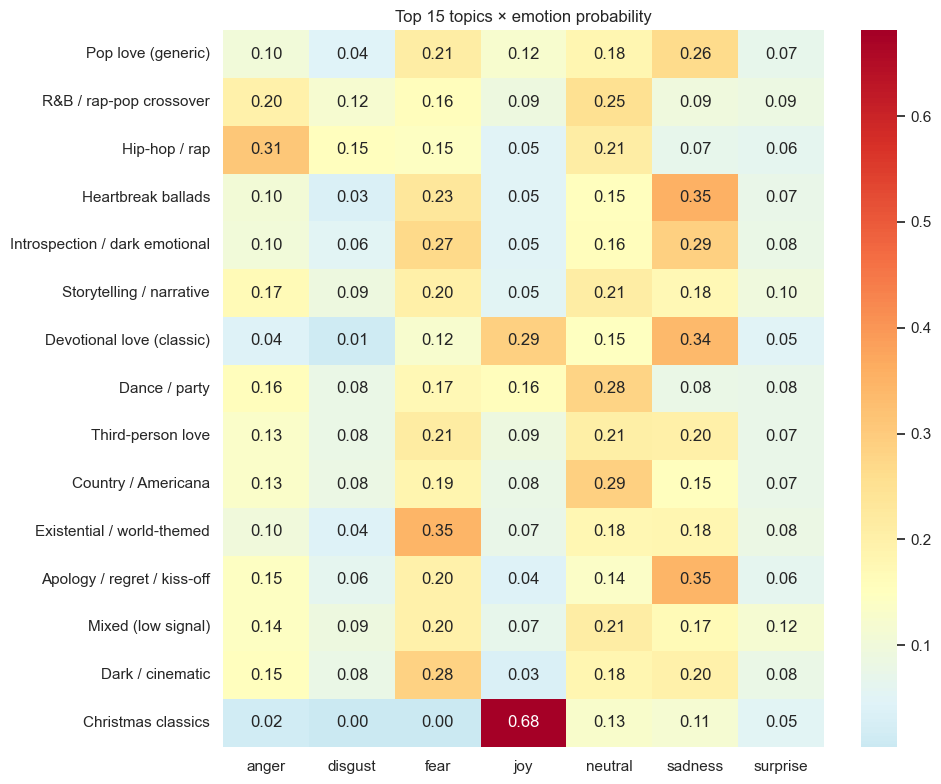

In [16]:
emo_cols = [c for c in df_en.columns if c.startswith("emo_")]

# Mean emotion probability per topic (top 15 topics)
top_topics_15 = (df_en[df_en["topic"] != -1]
                 .groupby("topic").size().nlargest(15).index)
topic_emo = (df_en[df_en["topic"].isin(top_topics_15)]
             .groupby("topic")[emo_cols].mean())
topic_emo.index = [TOPIC_NAMES.get(t, f"Topic {t}") for t in topic_emo.index]
topic_emo.columns = [c.replace("emo_", "") for c in topic_emo.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(topic_emo, cmap="RdYlBu_r", annot=True, fmt=".2f", center=0.15, ax=ax)
ax.set_title("Top 15 topics × emotion probability")
plt.tight_layout(); plt.show()

In [17]:
df_en.to_parquet(PROCESSED_DIR / "songs_with_topics.parquet")

# Save topic model itself for later use
topic_model.save(str(PROCESSED_DIR / "bertopic_model"),
                  serialization="safetensors",
                  save_ctfidf=True,
                  save_embedding_model="all-MiniLM-L6-v2")
print("Saved augmented dataset and topic model")

2026-05-15 11:13:28,562 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Saved augmented dataset and topic model
